# Просмотр БД Weaviate и RAG поиск по темам

Этот ноутбук позволяет:
1. Инспектировать содержимое Weaviate БД (статистика, схема, примеры)
2. Выполнять RAG поиск по темам из canonical_topics.jsonl
3. Визуализировать результаты поиска


In [1]:
import sys
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from typing import Any

# Добавляем путь к проекту
sys.path.insert(0, str(Path().absolute().parent))

import weaviate
from loguru import logger
from oasis.pipelines.stage2_indexing import hybrid_search


from IPython.display import display


# Настройки визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.width', None)

logger.info("Импорты загружены")


<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type swigvarlink has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
/home/skitarii/PycharmProjects/OASIS/.venv/lib/python3.12/site-packages/PyPDF2/__init__.py:21: DeprecationWarning: PyPDF2 is deprecated. Please move to the pypdf library instead.
  warnings.warn(
2025-11-23 21:01:00.293 | INFO     | __main__:<module>:29 - Импорты загружены


In [2]:
# Настройки
WEAVIATE_URL = "http://localhost:8081"
TOPICS_JSONL = Path("../outputs/deep_active_learning/canonical_topics.jsonl")

# Параметры поиска
TOPIC_NUMBER = 1  # Порядковый номер темы (1-based)
TOP_K = 10  # Количество результатов поиска
ALPHA = 0.5  # Вес векторного поиска (0.0 = только BM25, 1.0 = только векторный)
TEXT_PREVIEW_LENGTH = 200  # Длина превью текста в таблице

logger.info(f"Weaviate URL: {WEAVIATE_URL}")
logger.info(f"Topics file: {TOPICS_JSONL}")
logger.info(f"Topic number: {TOPIC_NUMBER}, Top-K: {TOP_K}, Alpha: {ALPHA}")


2025-11-23 21:01:00.300 | INFO     | __main__:<module>:11 - Weaviate URL: http://localhost:8081
2025-11-23 21:01:00.302 | INFO     | __main__:<module>:12 - Topics file: ../outputs/deep_active_learning/canonical_topics.jsonl
2025-11-23 21:01:00.303 | INFO     | __main__:<module>:13 - Topic number: 1, Top-K: 10, Alpha: 0.5


In [3]:
# Подключение к Weaviate
try:
    client = weaviate.Client(WEAVIATE_URL, startup_period=10)
    logger.success(f" Подключено к Weaviate: {WEAVIATE_URL}")
    
    # Проверка доступности
    is_live = client.is_live()
    is_ready = client.is_ready()
    logger.info(f"  is_live: {is_live}, is_ready: {is_ready}")
except Exception as e:
    logger.error(f" Ошибка подключения к Weaviate: {e}")
    logger.error("Убедитесь, что Weaviate запущен: docker compose up -d weaviate")
    raise


/home/skitarii/PycharmProjects/OASIS/.venv/lib/python3.12/site-packages/weaviate/warnings.py:121: DeprecationWarning: Dep005: You are using weaviate-client version 3.26.2. The latest version is 4.18.1.
            Please consider upgrading to the latest version. See https://weaviate.io/developers/weaviate/client-libraries/python for details.
  warnings.warn(
2025-11-23 21:01:00.697 | SUCCESS  | __main__:<module>:4 -  Подключено к Weaviate: http://localhost:8081
2025-11-23 21:01:00.706 | INFO     | __main__:<module>:9 -   is_live: True, is_ready: True


## 1. Статистика БД


In [4]:
# Количество объектов: Paper и Chunk
try:
    # Paper
    result_paper = client.query.aggregate("Paper").with_meta_count().do()
    paper_count = result_paper.get("data", {}).get("Aggregate", {}).get("Paper", [{}])[0].get("meta", {}).get("count", 0)
    
    # Chunk
    result_chunk = client.query.aggregate("Chunk").with_meta_count().do()
    chunk_count = result_chunk.get("data", {}).get("Aggregate", {}).get("Chunk", [{}])[0].get("meta", {}).get("count", 0)
    
    logger.info(f" Статистика БД:")
    logger.info(f"  Paper: {paper_count:,}")
    logger.info(f"  Chunk: {chunk_count:,}")
    if paper_count > 0:
        avg_chunks = chunk_count / paper_count
        logger.info(f"  Среднее чанков на Paper: {avg_chunks:.1f}")
except Exception as e:
    logger.error(f"Ошибка получения статистики: {e}")
    paper_count = 0
    chunk_count = 0


2025-11-23 21:01:00.729 | INFO     | __main__:<module>:11 -  Статистика БД:
2025-11-23 21:01:00.730 | INFO     | __main__:<module>:12 -   Paper: 189
2025-11-23 21:01:00.732 | INFO     | __main__:<module>:13 -   Chunk: 16,547
2025-11-23 21:01:00.733 | INFO     | __main__:<module>:16 -   Среднее чанков на Paper: 87.6


2025-11-23 21:01:00.771 | INFO     | __main__:<module>:15 - 
 Распределение по годам (всего 189 Paper):
2025-11-23 21:01:00.772 | INFO     | __main__:<module>:16 -   Годы: 1986 - 2024
2025-11-23 21:01:00.774 | INFO     | __main__:<module>:17 -   Медиана: 2021
2025-11-23 21:01:00.776 | INFO     | __main__:<module>:19 - 
 Распределение по типам:
2025-11-23 21:01:00.776 | INFO     | __main__:<module>:21 -   primary: 189


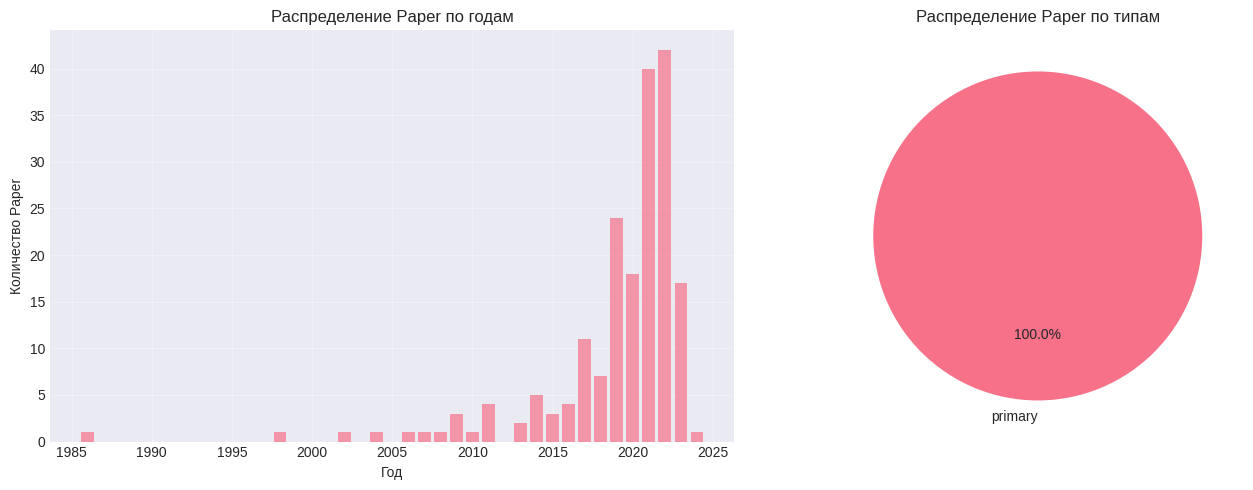

In [5]:
# Распределение по годам
try:
    result = client.query.get("Paper", ["year", "paper_type"]).with_limit(10000).do()
    papers = result.get("data", {}).get("Get", {}).get("Paper", [])
    
    if papers:
        df_papers = pd.DataFrame(papers)
        
        # Распределение по годам
        year_counts = df_papers["year"].value_counts().sort_index()
        
        # Распределение по paper_type
        type_counts = df_papers["paper_type"].value_counts()
        
        logger.info(f"\n Распределение по годам (всего {len(papers)} Paper):")
        logger.info(f"  Годы: {year_counts.index.min()} - {year_counts.index.max()}")
        logger.info(f"  Медиана: {df_papers['year'].median():.0f}")
        
        logger.info(f"\n Распределение по типам:")
        for ptype, count in type_counts.items():
            logger.info(f"  {ptype}: {count}")
        
        # Визуализация
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Гистограмма по годам
        axes[0].bar(year_counts.index, year_counts.values, alpha=0.7)
        axes[0].set_xlabel("Год")
        axes[0].set_ylabel("Количество Paper")
        axes[0].set_title("Распределение Paper по годам")
        axes[0].grid(True, alpha=0.3)
        
        # Pie chart по типам
        axes[1].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', startangle=90)
        axes[1].set_title("Распределение Paper по типам")
        
        plt.tight_layout()
        plt.show()
    else:
        logger.warning("Paper объекты не найдены")
except Exception as e:
    logger.error(f"Ошибка анализа распределений: {e}")


## 2. Схема БД


In [6]:
# Получение схемы
try:
    schema = client.schema.get()
    classes = schema.get("classes", [])
    
    logger.info(f" Схема БД: найдено {len(classes)} классов")
    logger.info("=" * 80)
    
    for class_info in classes:
        class_name = class_info.get("class", "Unknown")
        properties = class_info.get("properties", [])
        
        logger.info(f"\n Класс: {class_name}")
        logger.info(f"  Свойства ({len(properties)}):")
        
        for prop in properties:
            prop_name = prop.get("name", "?")
            prop_type = prop.get("dataType", ["?"])[0]
            logger.info(f"    - {prop_name}: {prop_type}")
        
        # Проверка связей для Chunk
        if class_name == "Chunk":
            has_parent = any(
                prop.get("name") == "parent" and "Paper" in prop.get("dataType", [])
                for prop in properties
            )
            if has_parent:
                logger.info("   Связь: parent -> Paper (parent-child)")
            else:
                logger.warning("  ️  Связь parent -> Paper не найдена")
except Exception as e:
    logger.error(f"Ошибка получения схемы: {e}")


2025-11-23 21:01:01.163 | INFO     | __main__:<module>:6 -  Схема БД: найдено 2 классов
2025-11-23 21:01:01.164 | INFO     | __main__:<module>:7 - ================================================================================
2025-11-23 21:01:01.166 | INFO     | __main__:<module>:13 - 
 Класс: Paper
2025-11-23 21:01:01.167 | INFO     | __main__:<module>:14 -   Свойства (7):
2025-11-23 21:01:01.169 | INFO     | __main__:<module>:19 -     - paper_id: text
2025-11-23 21:01:01.170 | INFO     | __main__:<module>:19 -     - title: text
2025-11-23 21:01:01.171 | INFO     | __main__:<module>:19 -     - year: int
2025-11-23 21:01:01.173 | INFO     | __main__:<module>:19 -     - doi: text
2025-11-23 21:01:01.174 | INFO     | __main__:<module>:19 -     - arxiv_id: text
2025-11-23 21:01:01.175 | INFO     | __main__:<module>:19 -     - venue: text
2025-11-23 21:01:01.176 | INFO     | __main__:<module>:19 -     - paper_type: text
2025-11-23 21:01:01.178 | INFO     | __main__:<module>:13 - 
 Класс:

## 3. Примеры объектов


In [7]:
# Примеры Paper объектов
try:
    # Запрашиваем только поля, которые есть в схеме Paper
    result = client.query.get(
        "Paper", 
        ["paper_id", "title", "year", "paper_type", "doi", "arxiv_id", "venue"]
    ).with_limit(5).do()
    
    # Проверяем структуру ответа для отладки
    if "data" not in result:
        logger.warning(f"Ответ Weaviate не содержит 'data': {list(result.keys())}")
        papers = []
    elif "Get" not in result["data"]:
        logger.warning(f"Ответ Weaviate не содержит 'data.Get': {list(result.get('data', {}).keys())}")
        papers = []
    elif "Paper" not in result["data"]["Get"]:
        logger.warning(f"Ответ Weaviate не содержит 'data.Get.Paper': {list(result.get('data', {}).get('Get', {}).keys())}")
        papers = []
    else:
        papers = result["data"]["Get"]["Paper"]
    
    if papers:
        logger.info(f" Примеры Paper объектов ({len(papers)}):")
        logger.info("=" * 80)
        
        for i, paper in enumerate(papers, 1):
            logger.info(f"\n{i}. Paper ID: {paper.get('paper_id', 'N/A')}")
            logger.info(f"   Название: {paper.get('title', 'N/A')[:100]}...")
            logger.info(f"   Год: {paper.get('year', 'N/A')}")
            logger.info(f"   Тип: {paper.get('paper_type', 'N/A')}")
            logger.info(f"   DOI: {paper.get('doi', 'N/A')}")
            logger.info(f"   arXiv ID: {paper.get('arxiv_id', 'N/A')}")
            logger.info(f"   Venue: {paper.get('venue', 'N/A')}")
    else:
        logger.warning("Paper объекты не найдены")
        logger.debug(f"Полный ответ Weaviate: {result}")
except Exception as e:
    logger.error(f"Ошибка получения Paper: {e}")
    import traceback
    logger.debug(traceback.format_exc())


2025-11-23 21:01:01.204 | INFO     | __main__:<module>:23 -  Примеры Paper объектов (5):
2025-11-23 21:01:01.205 | INFO     | __main__:<module>:24 - ================================================================================
2025-11-23 21:01:01.206 | INFO     | __main__:<module>:27 - 
1. Paper ID: 165-544
2025-11-23 21:01:01.207 | INFO     | __main__:<module>:28 -    Название: Active learning for networked data...
2025-11-23 21:01:01.209 | INFO     | __main__:<module>:29 -    Год: 2010
2025-11-23 21:01:01.210 | INFO     | __main__:<module>:30 -    Тип: primary
2025-11-23 21:01:01.212 | INFO     | __main__:<module>:31 -    DOI: nan
2025-11-23 21:01:01.213 | INFO     | __main__:<module>:32 -    arXiv ID: nan
2025-11-23 21:01:01.215 | INFO     | __main__:<module>:33 -    Venue: Proc. of ICML
2025-11-23 21:01:01.216 | INFO     | __main__:<module>:27 - 
2. Paper ID: 190-2023.acl-long.636
2025-11-23 21:01:01.217 | INFO     | __main__:<module>:28 -    Название: Counterfactual active lear

In [8]:
# Примеры Chunk объектов с метаданными
try:
    # Получаем разные чанки: сначала по разным paper_id, затем с разными позициями
    # Используем несколько запросов для получения разнообразных примеров
    all_chunks = []
    seen_paper_ids = set()
    seen_positions = set()
    
    # Первый запрос: получаем чанки из разных статей
    result1 = client.query.get(
        "Chunk",
        ["chunk_id", "text", "paper_id", "page_start", "page_end", "start_char", "end_char"]
    ).with_additional(["vector", "id"]).with_limit(20).do()
    
    chunks1 = result1.get("data", {}).get("Get", {}).get("Chunk", [])
    
    # Фильтруем: берем чанки из разных статей и с разными позициями
    for chunk in chunks1:
        paper_id = chunk.get('paper_id', '')
        pos_key = (chunk.get('start_char'), chunk.get('end_char'))
        
        # Берем чанк, если это новая статья или новая позиция
        if paper_id not in seen_paper_ids or pos_key not in seen_positions:
            all_chunks.append(chunk)
            seen_paper_ids.add(paper_id)
            seen_positions.add(pos_key)
            if len(all_chunks) >= 5:
                break
    
    # Если не набрали 5 разных, берем любые уникальные по позициям
    if len(all_chunks) < 5:
        for chunk in chunks1:
            pos_key = (chunk.get('start_char'), chunk.get('end_char'))
            if pos_key not in seen_positions:
                all_chunks.append(chunk)
                seen_positions.add(pos_key)
                if len(all_chunks) >= 5:
                    break
    
    chunks = all_chunks[:5]  # Берем первые 5
    
    if chunks:
        # Проверяем формат chunk_id (старый или новый)
        old_format_count = sum(1 for c in chunks if '::sec_' in c.get('chunk_id', ''))
        if old_format_count > 0:
            logger.warning(f"️  Обнаружены чанки со старым форматом ID (с 'sec_'): {old_format_count}/{len(chunks)}")
            logger.warning("   Это остатки от предыдущей индексации. Рекомендуется переиндексировать данные.")
        
        logger.info(f" Примеры Chunk объектов ({len(chunks)}):")
        logger.info("=" * 80)
        
        for i, chunk in enumerate(chunks, 1):
            additional = chunk.get("_additional", {})
            vector = additional.get("vector", [])
            
            chunk_id = chunk.get('chunk_id', 'N/A')
            logger.info(f"\n{i}. Chunk ID: {chunk_id}")
            logger.info(f"   Paper ID: {chunk.get('paper_id', 'N/A')}")
            logger.info(f"   Страницы: {chunk.get('page_start', 'N/A')}-{chunk.get('page_end', 'N/A')}")
            logger.info(f"   Позиция: {chunk.get('start_char', 'N/A')}-{chunk.get('end_char', 'N/A')}")
            logger.info(f"   Вектор: {'' if vector else ''} (размерность: {len(vector) if vector else 0})")
            text = chunk.get('text', '')
            # Показываем больше текста для проверки различий
            text_preview = text[:200].replace('\n', ' ').strip()
            logger.info(f"   Текст (первые 200 символов): {text_preview}...")
            
            # Проверка на дубликаты
            if i > 1:
                prev_chunk = chunks[i-2]
                if (chunk.get('start_char') == prev_chunk.get('start_char') and 
                    chunk.get('end_char') == prev_chunk.get('end_char')):
                    logger.warning(f"   ️  Дубликат позиции с предыдущим чанком!")
    else:
        logger.warning("Chunk объекты не найдены")
except Exception as e:
    logger.error(f"Ошибка получения Chunk: {e}")
    import traceback
    logger.debug(traceback.format_exc())


2025-11-23 21:01:01.469 | INFO     | __main__:<module>:49 -  Примеры Chunk объектов (5):
2025-11-23 21:01:01.470 | INFO     | __main__:<module>:50 - ================================================================================
2025-11-23 21:01:01.471 | INFO     | __main__:<module>:57 - 
1. Chunk ID: 76-sdata201635::chunk_017
2025-11-23 21:01:01.473 | INFO     | __main__:<module>:58 -    Paper ID: 76-sdata201635
2025-11-23 21:01:01.474 | INFO     | __main__:<module>:59 -    Страницы: 4-4
2025-11-23 21:01:01.476 | INFO     | __main__:<module>:60 -    Позиция: 11900-12900
2025-11-23 21:01:01.478 | INFO     | __main__:<module>:61 -    Вектор:  (размерность: 1024)
2025-11-23 21:01:01.479 | INFO     | __main__:<module>:65 -    Текст (первые 200 символов): 2. Distribution of primary International Classi fication of Diseases, 9th Edition (ICD-9) codes by care unit for patients aged 16 years and above. CCU is Coronary Care Unit; CSRU is Cardiac Surgery Re...
2025-11-23 21:01:01.479 | INFO   

## 4. Загрузка тем


In [9]:
# Загрузка тем из JSONL
def load_topics(jsonl_path: Path) -> list[dict[str, Any]]:
    """Загружает темы из JSONL файла."""
    topics = []
    if not jsonl_path.exists():
        logger.error(f"Файл тем не найден: {jsonl_path}")
        return topics
    
    with open(jsonl_path, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            try:
                topic = json.loads(line)
                topics.append(topic)
            except json.JSONDecodeError as e:
                logger.warning(f"Ошибка парсинга строки {line_num}: {e}")
    
    return topics

topics = load_topics(TOPICS_JSONL)
logger.info(f" Загружено тем: {len(topics)}")

# Отображение списка тем с порядковыми номерами
if topics:
    logger.info("\nСписок тем:")
    logger.info("=" * 80)
    for i, topic in enumerate(topics[:20], 1):  # Показываем первые 20
        logger.info(f"{i}. [{topic.get('canonical_topic_id', 'N/A')}] {topic.get('name', 'N/A')[:80]}...")
    if len(topics) > 20:
        logger.info(f"... и еще {len(topics) - 20} тем")
else:
    logger.warning("Темы не загружены")


2025-11-23 21:01:01.525 | INFO     | __main__:<module>:23 -  Загружено тем: 484
2025-11-23 21:01:01.526 | INFO     | __main__:<module>:27 - 
Список тем:
2025-11-23 21:01:01.527 | INFO     | __main__:<module>:28 - ================================================================================
2025-11-23 21:01:01.527 | INFO     | __main__:<module>:30 - 1. [CLUSTER_0001] Imbalance-Aware Adaptation in Stream-Based Active Learning...
2025-11-23 21:01:01.528 | INFO     | __main__:<module>:30 - 2. [CLUSTER_0002] Histopathology Datasets for Deep Active Learning Evaluation...
2025-11-23 21:01:01.529 | INFO     | __main__:<module>:30 - 3. [CLUSTER_0003] Cold-Start Strategies for 3D Medical Segmentation...
2025-11-23 21:01:01.530 | INFO     | __main__:<module>:30 - 4. [CLUSTER_0004] Deep Active Learning for Critical-Domain Information Extraction...
2025-11-23 21:01:01.531 | INFO     | __main__:<module>:30 - 5. [CLUSTER_0005] Generative Deep Active Learning for Aortic Stenosis...
2025-11-23 21:01

## 5. Выбор темы и RAG поиск


In [10]:
# Выбор темы по номеру
if not topics:
    logger.error("Темы не загружены. Пропускаем поиск.")
    selected_topic = None
else:
    if TOPIC_NUMBER < 1 or TOPIC_NUMBER > len(topics):
        logger.error(f"Неверный номер темы: {TOPIC_NUMBER} (доступно: 1-{len(topics)})")
        selected_topic = None
    else:
        selected_topic = topics[TOPIC_NUMBER - 1]
        logger.info(f" Выбрана тема #{TOPIC_NUMBER}:")
        logger.info(f"  ID: {selected_topic.get('canonical_topic_id', 'N/A')}")
        logger.info(f"  Название: {selected_topic.get('name', 'N/A')}")
        logger.info(f"  Описание: {selected_topic.get('description', 'N/A')}...")


2025-11-23 21:01:01.553 | INFO     | __main__:<module>:11 -  Выбрана тема #1:
2025-11-23 21:01:01.554 | INFO     | __main__:<module>:12 -   ID: CLUSTER_0001
2025-11-23 21:01:01.555 | INFO     | __main__:<module>:13 -   Название: Imbalance-Aware Adaptation in Stream-Based Active Learning
2025-11-23 21:01:01.556 | INFO     | __main__:<module>:14 -   Описание: This topic concerns mechanisms for handling class imbalance in active learning for data streams by adaptively reweighting ensemble classifiers. A damped class imbalance ratio (DCIR) is used as a streaming-aware indicator of how underrepresented each class is, based on its observed frequency over time. When a newly labeled instance is identified as belonging to a minority class via DCIR, a reinforcement-based update adjusts the dynamic classifier weights: classifiers are multiplicatively rewarded if they correctly predict the minority instance and penalized otherwise. These updates occur online after each queried label, allowing the 

In [11]:
# Выполнение RAG поиска
if selected_topic:
    # Формируем запрос из названия и описания темы
    topic_name = selected_topic.get('name', '')
    topic_desc = selected_topic.get('description', '')
    query = f"{topic_name}. {topic_desc}"
    
    logger.info(f"\n Выполнение RAG поиска...")
    logger.info(f"  Запрос: {query[:150]}...")
    logger.info(f"  Top-K: {TOP_K}, Alpha: {ALPHA}")
    
    try:
        search_results = hybrid_search(
            query=query,
            weaviate_client=client,
            top_k=TOP_K,
            alpha=ALPHA,
            trace_id="notebook_rag_search"
        )
        
        logger.success(f" Найдено результатов: {len(search_results)}")
    except Exception as e:
        logger.error(f" Ошибка поиска: {e}")
        search_results = []
else:
    search_results = []


2025-11-23 21:01:01.568 | INFO     | __main__:<module>:8 - 
 Выполнение RAG поиска...
2025-11-23 21:01:01.569 | INFO     | __main__:<module>:9 -   Запрос: Imbalance-Aware Adaptation in Stream-Based Active Learning. This topic concerns mechanisms for handling class imbalance in active learning for data st...
2025-11-23 21:01:01.570 | INFO     | __main__:<module>:10 -   Top-K: 10, Alpha: 0.5
2025-11-23 21:01:01.619 | INFO     | oasis.pipelines.stage2_indexing:_check_cuda_compatibility:448 - [trace_id=notebook_rag_search] Обнаружен GPU: NVIDIA GeForce GTX 1070 Ti, capability=6.1, devices=1
2025-11-23 21:01:01.788 | INFO     | oasis.pipelines.stage2_indexing:_check_cuda_compatibility:468 - [trace_id=notebook_rag_search] CUDA совместима и работает, используем GPU
2025-11-23 21:01:01.789 | INFO     | oasis.pipelines.stage2_indexing:hybrid_search:1126 - [trace_id=notebook_rag_search] Загрузка модели для векторизации запроса (device=cuda)...
2025-11-23 21:01:04.230 | INFO     | oasis.pipelines

## 6. Табличное представление результатов


In [12]:
# Создание DataFrame с результатами
if search_results:
    df_results = pd.DataFrame(search_results)
    
    # Преобразуем score в float (может быть строкой из Weaviate)
    df_results['score'] = pd.to_numeric(df_results['score'], errors='coerce')
    
    # Добавляем превью текста
    df_results['text_preview'] = df_results['text'].apply(
        lambda x: x[:TEXT_PREVIEW_LENGTH] + "..." if len(x) > TEXT_PREVIEW_LENGTH else x
    )
    
    # Сортировка по score (убывание)
    df_results = df_results.sort_values('score', ascending=False).reset_index(drop=True)
    
    # Выбираем колонки для отображения
    display_cols = ['chunk_id', 'paper_id', 'score', 'text_preview', 'page_start', 'page_end']
    df_display = df_results[display_cols].copy()
    
    logger.info(f"\n Таблица результатов (топ-{len(df_display)}):")
    logger.info("=" * 80)
    
    # Отображение таблицы
    display(df_display)
    
    # Статистика по score
    if df_results['score'].notna().any():
        logger.info(f"\n Статистика scores:")
        logger.info(f"  Мин: {df_results['score'].min():.4f}")
        logger.info(f"  Макс: {df_results['score'].max():.4f}")
        logger.info(f"  Среднее: {df_results['score'].mean():.4f}")
        logger.info(f"  Медиана: {df_results['score'].median():.4f}")
    else:
        logger.warning("Нет валидных scores для статистики")
else:
    logger.warning("Результаты поиска пусты")
    df_results = pd.DataFrame()


2025-11-23 21:01:04.243 | INFO     | __main__:<module>:20 - 
 Таблица результатов (топ-10):
2025-11-23 21:01:04.245 | INFO     | __main__:<module>:21 - ================================================================================


,chunk_id,paper_id,score,text_preview,page_start,page_end
0,28-s10994-023-06454-2::chunk_124,28-s10994-023-06454-2,0.945572,stable classifier andD dynamic classifiers was used by Zhang et al. ( 2022 ). They modified the original strategy by introducing a reinforcement mechanism to adjust the weights ω daccording to the...,27,27
1,28-s10994-023-06454-2::chunk_125,28-s10994-023-06454-2,0.694327,"nsider a hybrid strategy combining uncertainty samplingand random sampling, since approaches solely based on uncertainty could ignore a conceptchange that is not close to the boundary. Wo´ zniak e...",27,27
2,149-2204.07965v1::chunk_032,149-2204.07965v1,0.636483,"to favor certain classes ( i.e.the majority classes), leading to severe class imbalance. To deal with this issue, we increase the inter-class diversity by introducing the inter-class balancingproc...",5,5
3,28-s10994-023-06454-2::chunk_126,28-s10994-023-06454-2,0.628305,"cision boundary. Algorithm 4 Weight adjustment for dynamic classifiers Require: a labeled observation (xt,yt), number of classes K, number of dynamic classifiers D, current weights ωdwith d=1,...,...",27,28
4,25-mathematics-11-00820::chunk_090,25-mathematics-11-00820,0.541297,"es of obtaining instances from the minority classes. Consequently, active learners should improve their exploration ability to cover the whole space and find part of the minority class, especially...",18,18
5,196-2011.01285v1::chunk_009,196-2011.01285v1,0.460684,"EGAL robust to misspecified label sets and prove that this robustness only imposes a logarithmic cost over a hypothetical approach that knows the correct label set. Beyond these key contributions,...",2,2
6,23-KAIS.Fu.2013.Active::chunk_125,23-KAIS.Fu.2013.Active,0.410987,"f the drifting/ evolving data volumes, building a model based onall the labeled data may not be reasonable, while traditional active learning rely on a modelbuild from all the previously labeled d...",28,28
7,28-s10994-023-06454-2::chunk_115,28-s10994-023-06454-2,0.401684,"selectioncriterion is based on the predictive uncertainty, which they estimate using the best-versus-second-best margin value (Eq. 12), as they tackle a multi-class classification problem. An init...",25,25
8,149-2204.07965v1::chunk_031,149-2204.07965v1,0.390381,"ty between the prototypes instead of instance-level pair-wise comparison, thereby remarkably reducing the computational complexity, and 2) Mg(Ii;[C])encodes the similarity between intra-class prot...",5,5
9,28-s10994-023-06454-2::chunk_116,28-s10994-023-06454-2,0.389126,". Finally, the class imbalance issue is also taken into account in two ways,during the training of the ensemble with the use of class-specific weights, and during theactive learning routine, by dy...",25,25


2025-11-23 21:01:04.256 | INFO     | __main__:<module>:28 - 
 Статистика scores:
2025-11-23 21:01:04.257 | INFO     | __main__:<module>:29 -   Мин: 0.3891
2025-11-23 21:01:04.259 | INFO     | __main__:<module>:30 -   Макс: 0.9456
2025-11-23 21:01:04.260 | INFO     | __main__:<module>:31 -   Среднее: 0.5499
2025-11-23 21:01:04.262 | INFO     | __main__:<module>:32 -   Медиана: 0.5010


## 7. Развернутый формат результатов


In [13]:
# Развернутый формат для каждого результата
if search_results:
    logger.info(f"\n Развернутый формат результатов:")
    logger.info("=" * 80)
    
    for i, result in enumerate(search_results, 1):
        # Преобразуем score в float (может быть строкой из Weaviate)
        score = result.get('score', 0.0)
        try:
            score = float(score) if score is not None else 0.0
        except (ValueError, TypeError):
            score = 0.0
        
        logger.info(f"\n{'='*80}")
        logger.info(f"Результат #{i} (Score: {score:.4f})")
        logger.info(f"{'='*80}")
        logger.info(f"Chunk ID: {result.get('chunk_id', 'N/A')}")
        logger.info(f"Paper ID: {result.get('paper_id', 'N/A')}")
        logger.info(f"Страницы: {result.get('page_start', 'N/A')}-{result.get('page_end', 'N/A')}")
        logger.info(f"Позиция в тексте: {result.get('start_char', 'N/A')}-{result.get('end_char', 'N/A')}")
        logger.info(f"\nПолный текст чанка:")
        logger.info(f"{'-'*80}")
        logger.info(result.get('text', 'N/A'))
        logger.info(f"{'-'*80}")
else:
    logger.warning("Результаты поиска пусты")


2025-11-23 21:01:04.273 | INFO     | __main__:<module>:3 - 
 Развернутый формат результатов:
2025-11-23 21:01:04.275 | INFO     | __main__:<module>:4 - ================================================================================
2025-11-23 21:01:04.276 | INFO     | __main__:<module>:14 - 
2025-11-23 21:01:04.277 | INFO     | __main__:<module>:15 - Результат #1 (Score: 0.9456)
2025-11-23 21:01:04.278 | INFO     | __main__:<module>:16 - ================================================================================
2025-11-23 21:01:04.279 | INFO     | __main__:<module>:17 - Chunk ID: 28-s10994-023-06454-2::chunk_124
2025-11-23 21:01:04.280 | INFO     | __main__:<module>:18 - Paper ID: 28-s10994-023-06454-2
2025-11-23 21:01:04.281 | INFO     | __main__:<module>:19 - Страницы: 27-27
2025-11-23 21:01:04.282 | INFO     | __main__:<module>:20 - Позиция в тексте: 86800-87800
2025-11-23 21:01:04.283 | INFO     | __main__:<module>:21 - 
Полный текст чанка:
2025-11-23 21:01:04.283 | INFO    

## 8. Визуализация результатов


/tmp/ipykernel_291926/1357660341.py:17: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  ax2.boxplot(df_results['score'], vert=True)


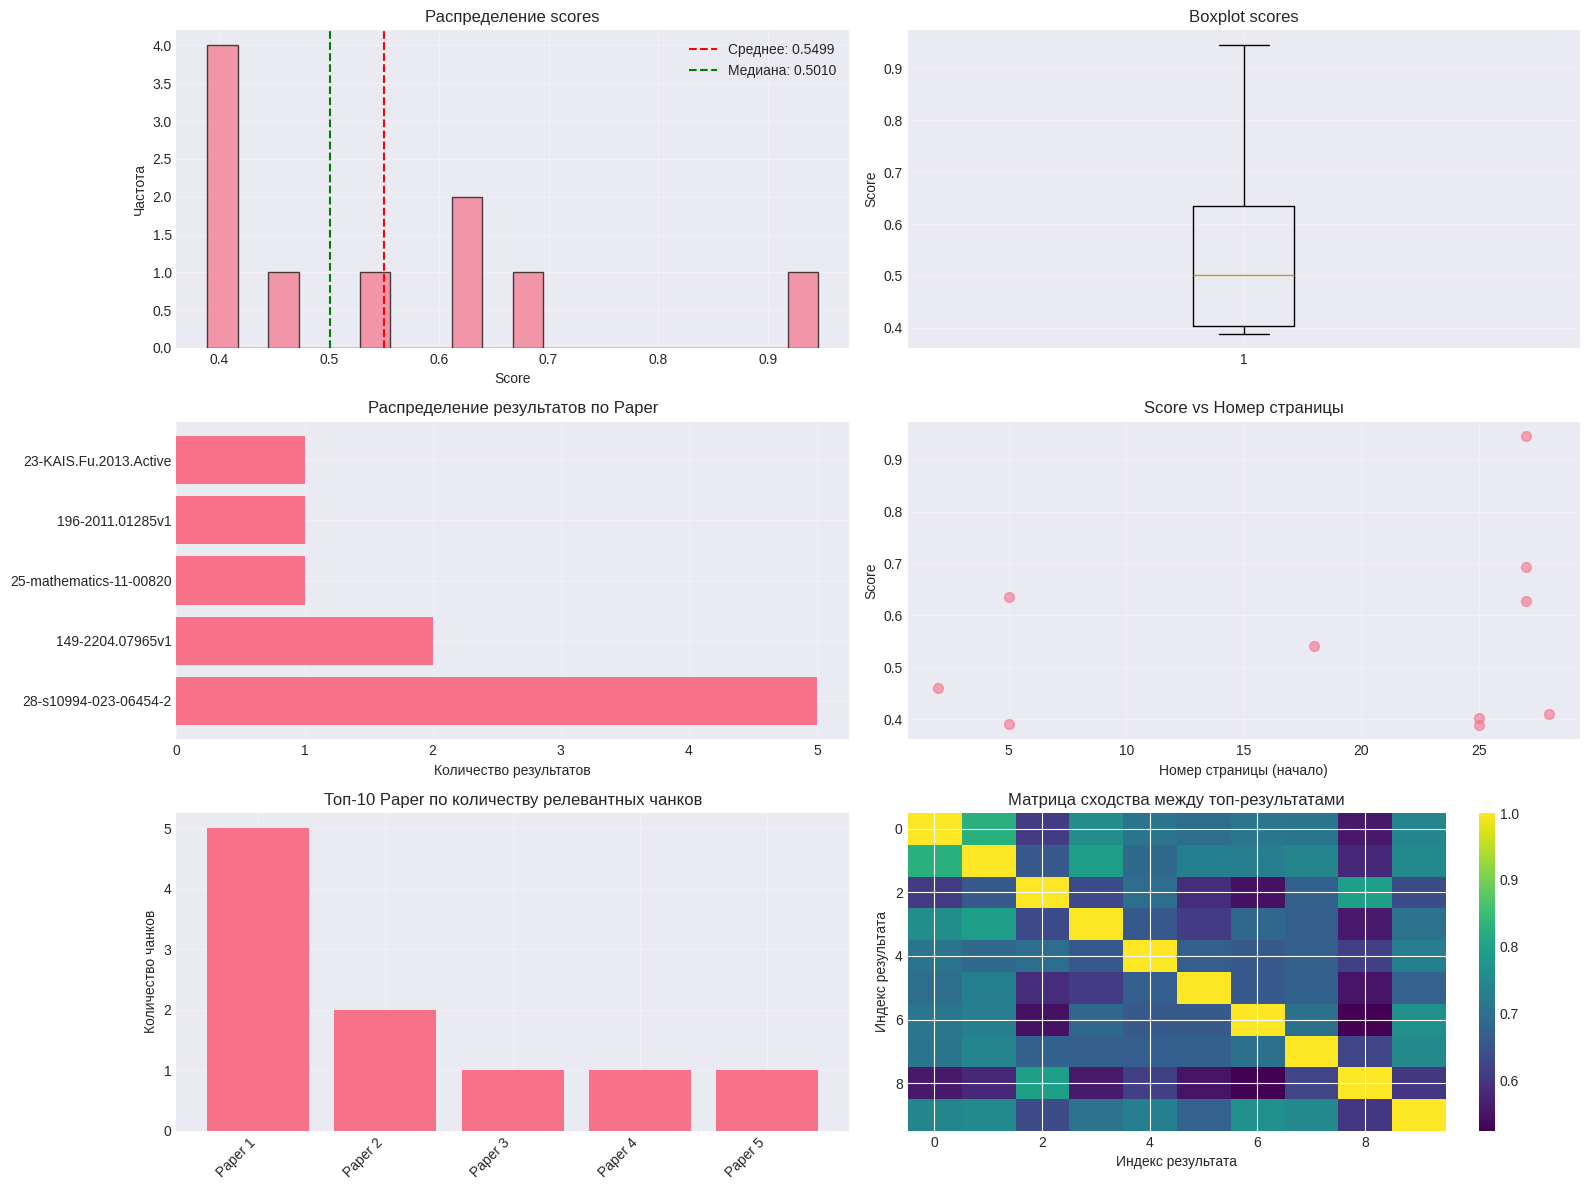

2025-11-23 21:01:05.585 | INFO     | __main__:<module>:103 -  Визуализации созданы


In [14]:
# Визуализации результатов поиска
if not df_results.empty:
    fig = plt.figure(figsize=(16, 12))
    
    # 1. Распределение scores (гистограмма + boxplot)
    ax1 = plt.subplot(3, 2, 1)
    ax1.hist(df_results['score'], bins=20, alpha=0.7, edgecolor='black')
    ax1.axvline(df_results['score'].mean(), color='red', linestyle='--', label=f'Среднее: {df_results["score"].mean():.4f}')
    ax1.axvline(df_results['score'].median(), color='green', linestyle='--', label=f'Медиана: {df_results["score"].median():.4f}')
    ax1.set_xlabel('Score')
    ax1.set_ylabel('Частота')
    ax1.set_title('Распределение scores')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2 = plt.subplot(3, 2, 2)
    ax2.boxplot(df_results['score'], vert=True)
    ax2.set_ylabel('Score')
    ax2.set_title('Boxplot scores')
    ax2.grid(True, alpha=0.3)
    
    # 2. Распределение по Paper (bar chart)
    ax3 = plt.subplot(3, 2, 3)
    paper_counts = df_results['paper_id'].value_counts()
    ax3.barh(range(len(paper_counts)), paper_counts.values)
    ax3.set_yticks(range(len(paper_counts)))
    ax3.set_yticklabels([pid[:30] + '...' if len(pid) > 30 else pid for pid in paper_counts.index])
    ax3.set_xlabel('Количество результатов')
    ax3.set_title('Распределение результатов по Paper')
    ax3.grid(True, alpha=0.3)
    
    # 3. Scatter plot: page_start vs score
    ax4 = plt.subplot(3, 2, 4)
    if 'page_start' in df_results.columns and df_results['page_start'].notna().any():
        ax4.scatter(df_results['page_start'], df_results['score'], alpha=0.6, s=50)
        ax4.set_xlabel('Номер страницы (начало)')
        ax4.set_ylabel('Score')
        ax4.set_title('Score vs Номер страницы')
        ax4.grid(True, alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'Нет данных о страницах', ha='center', va='center', transform=ax4.transAxes)
        ax4.set_title('Score vs Номер страницы (нет данных)')
    
    # 4. Топ Paper по количеству релевантных чанков
    ax5 = plt.subplot(3, 2, 5)
    top_papers = paper_counts.head(10)  # Топ-10
    if len(top_papers) > 0:
        ax5.bar(range(len(top_papers)), top_papers.values)
        ax5.set_xticks(range(len(top_papers)))
        ax5.set_xticklabels([f"Paper {i+1}" for i in range(len(top_papers))], rotation=45, ha='right')
        ax5.set_ylabel('Количество чанков')
        ax5.set_title('Топ-10 Paper по количеству релевантных чанков')
        ax5.grid(True, alpha=0.3)
    else:
        ax5.text(0.5, 0.5, 'Нет данных', ha='center', va='center', transform=ax5.transAxes)
        ax5.set_title('Топ Paper (нет данных)')
    
    # 5. Heatmap: матрица сходства между топ-результатами (если есть векторы)
    ax6 = plt.subplot(3, 2, 6)
    try:
        # Получаем векторы для топ-результатов
        chunk_ids = df_results['chunk_id'].head(10).tolist()
        if chunk_ids:
            vectors = []
            valid_chunk_ids = []
            for chunk_id in chunk_ids:
                try:
                    result = client.query.get("Chunk", ["chunk_id"]).with_additional(["vector"]).with_where({
                        "path": ["chunk_id"],
                        "operator": "Equal",
                        "valueText": chunk_id
                    }).with_limit(1).do()
                    chunks = result.get("data", {}).get("Get", {}).get("Chunk", [])
                    if chunks and chunks[0].get("_additional", {}).get("vector"):
                        vectors.append(chunks[0]["_additional"]["vector"])
                        valid_chunk_ids.append(chunk_id)
                except:
                    continue
            
            if len(vectors) >= 2:
                # Вычисляем косинусное сходство
                vectors_array = np.array(vectors)
                similarity_matrix = np.dot(vectors_array, vectors_array.T)
                
                im = ax6.imshow(similarity_matrix, cmap='viridis', aspect='auto')
                ax6.set_title('Матрица сходства между топ-результатами')
                ax6.set_xlabel('Индекс результата')
                ax6.set_ylabel('Индекс результата')
                plt.colorbar(im, ax=ax6)
            else:
                ax6.text(0.5, 0.5, 'Недостаточно векторов для heatmap', ha='center', va='center', transform=ax6.transAxes)
                ax6.set_title('Heatmap (нет данных)')
        else:
            ax6.text(0.5, 0.5, 'Нет chunk_id для получения векторов', ha='center', va='center', transform=ax6.transAxes)
            ax6.set_title('Heatmap (нет данных)')
    except Exception as e:
        ax6.text(0.5, 0.5, f'Ошибка создания heatmap: {str(e)[:50]}', ha='center', va='center', transform=ax6.transAxes)
        ax6.set_title('Heatmap (ошибка)')
    
    plt.tight_layout()
    plt.show()
    
    logger.info(" Визуализации созданы")
else:
    logger.warning("Нет данных для визуализации")
